In [79]:
transitions = {
    "A": {"A": 0.2, "B": 0.4, "C": 0.4},
    "B": {"A": 0.3, "C": 0.7},
    "C": {"A": 0.5, "B": 0.3, "C": 0.2},
}

In [7]:
from graphviz import Digraph
from IPython.display import Image
import numpy as np

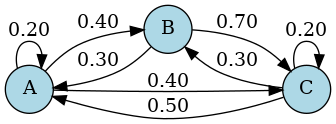

In [ ]:
def draw_markov_chain(transitions, filename="markov_chain"):
    dot = Digraph(format="png")
    dot.attr(rankdir="LR", size="10") 

    # nodes
    for state in transitions.keys():
        dot.node(state, shape="circle", style="filled", fillcolor="lightblue")

    # arrows + labels
    for u, probs in transitions.items():
        for v, p in probs.items():
            if p > 0:
                dot.edge(u, v, label=f"{p:.2f}")

    return dot.render(filename, view=False, overwrite_source=True)

img = draw_markov_chain(transitions)
Image(img)

In [80]:
# add in transitions cumulative frequency
from copy import deepcopy

transitions_cumulative = deepcopy(transitions)

for key, dict in transitions_cumulative.items():
    cumulative_freq = 0
    if dict is None:
        pass
    for dict_key, value in dict.items():
        transitions_cumulative[key][dict_key] += cumulative_freq
        cumulative_freq += value

print(transitions)
print(transitions_cumulative)

{'A': {'A': 0.2, 'B': 0.4, 'C': 0.4}, 'B': {'A': 0.3, 'C': 0.7}, 'C': {'A': 0.5, 'B': 0.3, 'C': 0.2}}
{'A': {'A': 0.2, 'B': 0.6000000000000001, 'C': 1.0}, 'B': {'A': 0.3, 'C': 1.0}, 'C': {'A': 0.5, 'B': 0.8, 'C': 1.0}}


In [69]:
starting_node = 0 # A
num_steps = 10_000_000
from random import random

node_counter = [0 for _ in range(len(transitions_cumulative.keys()))]
node_counter[starting_node] += 1

idx_to_node = {0: 'A', 1: 'B', 2: 'C'}
node_to_idx = {'A': 0, 'B': 1, 'C': 2}

current_node = starting_node
for j in range(1, num_steps):
    rand = random()
    for dict_key, cumulative_freq in transitions_cumulative[idx_to_node[current_node]].items():
        if rand < cumulative_freq:
            current_node = node_to_idx[dict_key]
            node_counter[current_node] += 1
            break

print(node_counter)

assert sum(node_counter) == num_steps, "Something's wrong here!"

perc_node = [x / num_steps for x in node_counter]
print(perc_node)

[3450866, 2572187, 3976947]
[0.3450866, 0.2572187, 0.3976947]


In [70]:
starting_node = 1 # B
num_steps = 10_000_000
from random import random

node_counter = [0 for _ in range(len(transitions_cumulative.keys()))]
node_counter[starting_node] += 1

idx_to_node = {0: 'A', 1: 'B', 2: 'C'}
node_to_idx = {'A': 0, 'B': 1, 'C': 2}

current_node = starting_node
for j in range(1, num_steps):
    rand = random()
    for dict_key, cumulative_freq in transitions_cumulative[idx_to_node[current_node]].items():
        if rand < cumulative_freq:
            current_node = node_to_idx[dict_key]
            node_counter[current_node] += 1
            break

print(node_counter)

assert sum(node_counter) == num_steps, "Something's wrong here!"

perc_node = [x / num_steps for x in node_counter]
print(perc_node)

[3449948, 2572963, 3977089]
[0.3449948, 0.2572963, 0.3977089]


In [71]:
starting_node = 2 # C
num_steps = 10_000_000
from random import random

node_counter = [0 for _ in range(len(transitions_cumulative.keys()))]
node_counter[starting_node] += 1

idx_to_node = {0: 'A', 1: 'B', 2: 'C'}
node_to_idx = {'A': 0, 'B': 1, 'C': 2}

current_node = starting_node
for j in range(1, num_steps):
    rand = random()
    for dict_key, cumulative_freq in transitions_cumulative[idx_to_node[current_node]].items():
        if rand < cumulative_freq:
            current_node = node_to_idx[dict_key]
            node_counter[current_node] += 1
            break

print(node_counter)

assert sum(node_counter) == num_steps, "Something's wrong here!"

perc_node = [x / num_steps for x in node_counter]
print(perc_node)

[3450903, 2573912, 3975185]
[0.3450903, 0.2573912, 0.3975185]


As we can see, the starting node does not change percentage.

For solving Markov Chain problems is always suggested to use the Transition Matrix $A$ where $A_{ij}$ is equals to the probability of going from node $i$ to node $j$ directly.

In [ ]:
# Transition Matrix
matrix = np.zeros((3,3))
matrix *= 0

node_to_idx = {'A': 0, 'B': 1, 'C': 2}

for key, dict in transitions.items():
    for dict_key, value in dict.items():
        matrix[node_to_idx[key], node_to_idx[dict_key]] = value

print(matrix)

[[0.2 0.4 0.4]
 [0.3 0.  0.7]
 [0.5 0.3 0.2]]


In [103]:
num_iterations = 1_000
pi = [None for _ in range(num_iterations)]

pi[0] = np.array([0, 1, 0])

for idx in range(num_iterations-1):
    pi[idx+1] = pi[idx] @ matrix # @ -> dot product

print(pi[0], pi[1], pi[2], pi[3], '...', pi[-1])

[0 1 0] [0.3 0.  0.7] [0.41 0.33 0.26] [0.311 0.242 0.447] ... [0.34502924 0.25730994 0.39766082]


We arrive in the condition: $\pi A = \pi$ (left eigenvector with eigenvalue = 1)

In [113]:
# find left eigenvector
matrix_t = matrix.transpose()

eigenvalues, eigenvectors = np.linalg.eig(matrix_t)
print("1 is eigenvalue" if any([np.round(eigenvalue, 10) == 1 for eigenvalue in eigenvalues]) else "1 is not eigenvalue")

print(eigenvectors)

idx = np.argmin(np.abs(eigenvalues - 1))
stationary = np.real(eigenvectors[:, idx])

# Normalizza così che sommi a 1
stationary = stationary / np.sum(stationary)

print(pi := stationary)

1 is eigenvalue
[[ 0.58879421+0.j         -0.47140452-0.33333333j -0.47140452+0.33333333j]
 [ 0.43910076+0.j         -0.23570226+0.33333333j -0.23570226-0.33333333j]
 [ 0.67861027+0.j          0.70710678+0.j          0.70710678-0.j        ]]
[0.34502924 0.25730994 0.39766082]


What's the probability to reach node $j$ starting from node $i$ after $n$ steps? The value is called $P_{ij}(n)$ and this problem is called __n-step transition__.

The probability for $n = 1$ is really simple to evaluate. In fact, by definition: $$P_{ij}(1) = A_{ij}$$ where $A$ is the Transition Matrix.

What happen if I want to evaluate $P_{ij}(2)$? Let's see using an example.

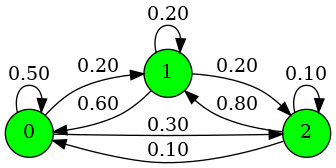

In [5]:
transitions = [
    [0.5, 0.2, 0.3],
    [0.6, 0.2, 0.2],
    [0.1, 0.8, 0.1],
]

def draw_markov_chain_from_array(transitions, filename="markov_chain_2"):
    dot = Digraph(format="png")
    dot.attr(rankdir="LR", size="10") 

    # nodes
    for state in range(len(transitions)):
        dot.node(str(state), shape="circle", style="filled", fillcolor="green")

    # arrows + labels
    for u, probs in enumerate(transitions):
        for v, p in enumerate(probs):
            if p > 0:
                dot.edge(str(u), str(v), label=f"{p:.2f}")

    return dot.render(filename, view=False, overwrite_source=True)

img = draw_markov_chain_from_array(transitions)
Image(img)

Let's calculate $P_{02}(2)$.

First way I saw is $0 \rightarrow 1 \rightarrow 2$.

Another one is $0 \rightarrow 0 \rightarrow 2$.

The third and last one is $0 \rightarrow 2 \rightarrow 2$.

$$P_{02}(2) = A_{01} \cdot A_{12} + A_{00} \cdot A_{02} + A_{02} \cdot A_{22}$$

Rearranging the sum we obtain $$ P_{02}(2) = A_{00} \cdot A_{02} + A_{01} \cdot A_{12} + A_{02} \cdot A_{22} $$

We can write this sum using Sigma $\Sigma$ notation.

$$P_{02}(2) = \sum_{i=0}^2 A_{0i} \cdot A_{i2}$$

Have you already understood what this is? Yeah, that's simply $A^2_{02}$.

In general: $$P_{ij}(2) = A^2_{ij}$$

More specifically: $$P_{ij}(n) = A^n_{ij}$$

In [8]:
transitions = np.matrix(transitions)

In [14]:
# Evaluate P_02(2)

STEPS = 100
n_step_transitions = [None] * STEPS

n_step_transitions[0] = transitions

for i in range(1, STEPS):
    n_step_transitions[i] = n_step_transitions[i-1] @ transitions

print(n_step_transitions[1])
print("The probability of reaching node 2 starting from node 0 after 2 step is", n_step_transitions[1][0,2])

[[0.4  0.38 0.22]
 [0.44 0.32 0.24]
 [0.54 0.26 0.2 ]]
The probability of reaching node 2 starting from node 0 after 2 step is 0.22


In [15]:
print(n_step_transitions[0])
print(n_step_transitions[1])
print(n_step_transitions[2])
print(n_step_transitions[-1])

[[0.5 0.2 0.3]
 [0.6 0.2 0.2]
 [0.1 0.8 0.1]]
[[0.4  0.38 0.22]
 [0.44 0.32 0.24]
 [0.54 0.26 0.2 ]]
[[0.45  0.332 0.218]
 [0.436 0.344 0.22 ]
 [0.446 0.32  0.234]]
[[0.44444444 0.33333333 0.22222222]
 [0.44444444 0.33333333 0.22222222]
 [0.44444444 0.33333333 0.22222222]]


Last matrix corresponds to $\pi$ (eigenvector of $A$ with left eigenvalue $\lambda = 1$)

We can verify that.

In [16]:
matrix_t = transitions.transpose()

eigenvalues, eigenvectors = np.linalg.eig(matrix_t)
print("1 is eigenvalue" if any([np.round(eigenvalue, 10) == 1 for eigenvalue in eigenvalues]) else "1 is not eigenvalue")

print(eigenvectors)

idx = np.argmin(np.abs(eigenvalues - 1))
stationary = np.real(eigenvectors[:, idx])

# Normalizza così che sommi a 1
stationary = stationary / np.sum(stationary)

print(pi := stationary)

1 is eigenvalue
[[ 0.74278135+0.j          0.58925565+0.26352314j  0.58925565-0.26352314j]
 [ 0.55708601+0.j         -0.70710678+0.j         -0.70710678-0.j        ]
 [ 0.37139068+0.j          0.11785113-0.26352314j  0.11785113+0.26352314j]]
[[0.44444444]
 [0.33333333]
 [0.22222222]]


Another important concept is that every column has the same value. No matter the starting node.